In [2]:
import mocet
import os
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def coefs_normalize(coefs_):
    coefs_new = []
    for i in range(2):
        trans_scale = np.mean(np.abs(coefs_[i][:3]))
        rot_scale = np.mean(np.abs(coefs_[i][3:6]))
        scale_ratio = 100 #*rot_scale/trans_scale
        coefs_new.append(np.array(np.concatenate([coefs_[i][:3]*scale_ratio, coefs_[i][3:]])))
    return coefs_new

subject_pool = {
                'sub-003':{'ses-07R':([1,2,3,4,5], False),
                           'ses-13R':([1,2,4,5,6], False)},
                'sub-004':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-005':{'ses-07':([1,2,3,4,5,6], True)},
                'sub-006':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-008':{'ses-07R':([2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-009':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,5,6], False)},
                'sub-010':{'ses-07':([1,2,3,4,5], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-011':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-012':{'ses-07':([1,2,4,5,6], False)},
                'sub-013':{'ses-07':([1,2,3,4], False)},
                'sub-014':{'ses-07':([2,3,4,5,6], False)},
                'sub-015':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-016':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-017':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5], False)},
                'sub-018':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-020':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-021':{'ses-07':([1,2,4,5,6], False),
                           'ses-13':([1,2,4,5,6], False)},
                'sub-JJY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-KMY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-PJW':{'ses-07':([1,2,3,4,6], True)},
                'sub-PBJ':{'ses-07':([1,2,3,4,5], False)}
                }


history_onset = {'sub-003': [34.1, 26.1, 31.9, 24.9, 21.7, 18.0],
                 'sub-005': [28.66, 29.32, 28.12, 33.7, 36.1, 27.46],
                 'sub-PJW': [35, 30.8, 28.66, 26.58, None, 27.42]}
task_duration = 816

calibration_onsets = [1, 494]
calibration_points = [24, 12]
interval = 1.6 
calibration_offset_start = 0.5
calibration_offset_end = -0.5
t_cal = 0

motion_param_labels = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

testable_data = pickle.load(open('../testable_data_list.pkl', 'rb'))

simulation_log_fname = f'../Figure_2/data/simulation_log.csv'
simulation_log = pd.read_csv(simulation_log_fname)
simulation_pupil_data = simulation_log[["center_x","center_y","diameter_px"]].to_numpy()

print(simulation_pupil_data.shape)
duration_tr = 510

key_simulation_pupil_data = []
key_simulation_pupil_size = []
k = 0
for key in testable_data.keys():
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    data = simulation_pupil_data[k*duration_tr:(k+1)*duration_tr,:]
    for i in range(510):
        if data[i, 0] == -1:
            data[i,:] = data[i-1,:]
    key_simulation_pupil_data.append(data[:,:2])
    key_simulation_pupil_size.append(data[:,2])
    k += 1


(56610, 3)


In [3]:
subject_coefs_x = {}
subject_coefs_y = {}

for key in testable_data.keys():
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])

    root = f'../../_DATA/{subject}/{session}'
    log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
    data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt'
    confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'

    runs, history_loss = subject_pool[subject][session]
    if history_loss: 
        start = history_onset[subject][r-1]
    else:
        history_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_his.txt'
        start, _, _ = mocet.utils.get_avotec_history(history_fname)

    # log, data, confound, start
    pupil_data, pupil_timestamps, pupil_confidence, pupil_diameter = mocet.utils.clean_avotec_data(log_fname,
                                                                                            data_fname,
                                                                                            start=start,
                                                                                            duration=task_duration)
    avg_pupil_diameter_mm = 5
    pupil_diameter_mm_per_px = avg_pupil_diameter_mm / np.nanmean(pupil_diameter)
    pupil_data_new = np.zeros_like(pupil_data)
    pupil_data_new[:,0] = pupil_data[:,0] - np.mean(pupil_data[:int(1.6*25*60),0])
    pupil_data_new[:,1] = pupil_data[:,1] - np.mean(pupil_data[:int(1.6*25*60),1])
    pupil_data_new = pupil_data_new * pupil_diameter_mm_per_px

    pupil_data, coefs_, _ = mocet.apply_mocet(pupil_data_new, confounds_fname,
                                           large_motion_params=False,
                                           polynomial_order=3, 
                                           return_weights=True,
                                           use_mm_deg=True)
    
    if not subject_coefs_x.keys().__contains__(subject):
        subject_coefs_x[subject] = []
        subject_coefs_y[subject] = []
    coefs_ = coefs_normalize(coefs_)
    #x_coefs = np.concatenate([coefs_[0].reshape(-1,1), coefs_[0][0].reshape(-1,1)]) #append last element
    #y_coefs = np.concatenate([coefs_[1].reshape(-1,1), coefs_[1][0].reshape(-1,1)])
    #subject_coefs_x[subject].append(x_coefs)
    #subject_coefs_y[subject].append(y_coefs)
    subject_coefs_x[subject].append(coefs_[0])
    subject_coefs_y[subject].append(coefs_[1])

subjects_coefs_x = []
subjects_coefs_y = []
for key in subject_coefs_x.keys():
    subjects_coefs_x.append(np.mean(subject_coefs_x[key], axis=0))
    subjects_coefs_y.append(np.mean(subject_coefs_y[key], axis=0))
    #subjects_coefs_x += subject_coefs_x[key]
    #subjects_coefs_y += subject_coefs_y[key]


In [4]:
model_coefs_x = {}
model_coefs_y = {}

for k, key in enumerate(testable_data.keys()):
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    root = f'../../_DATA/{subject}/{session}'
    confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
    
    model_pupil_data = key_simulation_pupil_data[k]
    model_pupil_size = key_simulation_pupil_size[k]

    avg_pupil_diameter_mm = 5
    pupil_diameter_mm_per_px = avg_pupil_diameter_mm / np.nanmean(model_pupil_size)
    pupil_data_new = np.zeros_like(model_pupil_data)
    pupil_data_new[:,0] = model_pupil_data[:,0] - np.mean(model_pupil_data[:25,0])
    pupil_data_new[:,1] = model_pupil_data[:,1] - np.mean(model_pupil_data[:25,1])
    pupil_data_new = pupil_data_new * pupil_diameter_mm_per_px

    model_pupil_data, coefs_, _ = mocet.apply_mocet(pupil_data_new, confounds_fname,
                                                 large_motion_params=False,
                                                 polynomial_order=3, 
                                                 return_weights=True,
                                                 use_mm_deg=True)
    
    if not model_coefs_x.keys().__contains__(subject):
        model_coefs_x[subject] = []
        model_coefs_y[subject] = []
    coefs_ = coefs_normalize(coefs_)
    #x_coefs = np.concatenate([coefs_[0].reshape(-1,1), coefs_[0][0].reshape(-1,1)])
    #y_coefs = np.concatenate([coefs_[1].reshape(-1,1), coefs_[1][0].reshape(-1,1)])
    #model_coefs_x[subject].append(x_coefs)
    #model_coefs_y[subject].append(y_coefs)
    model_coefs_x[subject].append(coefs_[0])
    model_coefs_y[subject].append(coefs_[1])

models_coefs_x = []
models_coefs_y = []
for key in subject_coefs_x.keys():
    models_coefs_x.append(np.mean(model_coefs_x[key], axis=0))
    models_coefs_y.append(np.mean(model_coefs_y[key], axis=0))
    #models_coefs_x += model_coefs_x[key]
    #models_coefs_y += model_coefs_y[key]
    
    

In [5]:
from scipy.stats import ttest_rel

t_stat_x, p_val_x = ttest_rel(subjects_coefs_x, models_coefs_x, axis=0)
t_stat_y, p_val_y = ttest_rel(subjects_coefs_y, models_coefs_y, axis=0)

print("T-test results for X coefficients:")
#print("T-statistic: ", t_stat_x)
print("P-value: ", p_val_x)

print("T-test results for Y coefficients:")
#print("T-statistic: ", t_stat_y)
print("P-value: ", p_val_y)

T-test results for X coefficients:
P-value:  [5.77372139e-02 2.65301813e-01 2.79228444e-01 1.37702893e-01
 2.88400933e-04 8.49255324e-02 1.44286064e-01 8.06543460e-01
 7.39535121e-01 4.47572644e-01]
T-test results for Y coefficients:
P-value:  [9.19596353e-01 4.02340899e-02 2.79002316e-05 1.25714093e-05
 5.67151205e-01 9.03864707e-01 7.69887139e-01 6.31529667e-01
 1.50473887e-02 1.36835336e-03]


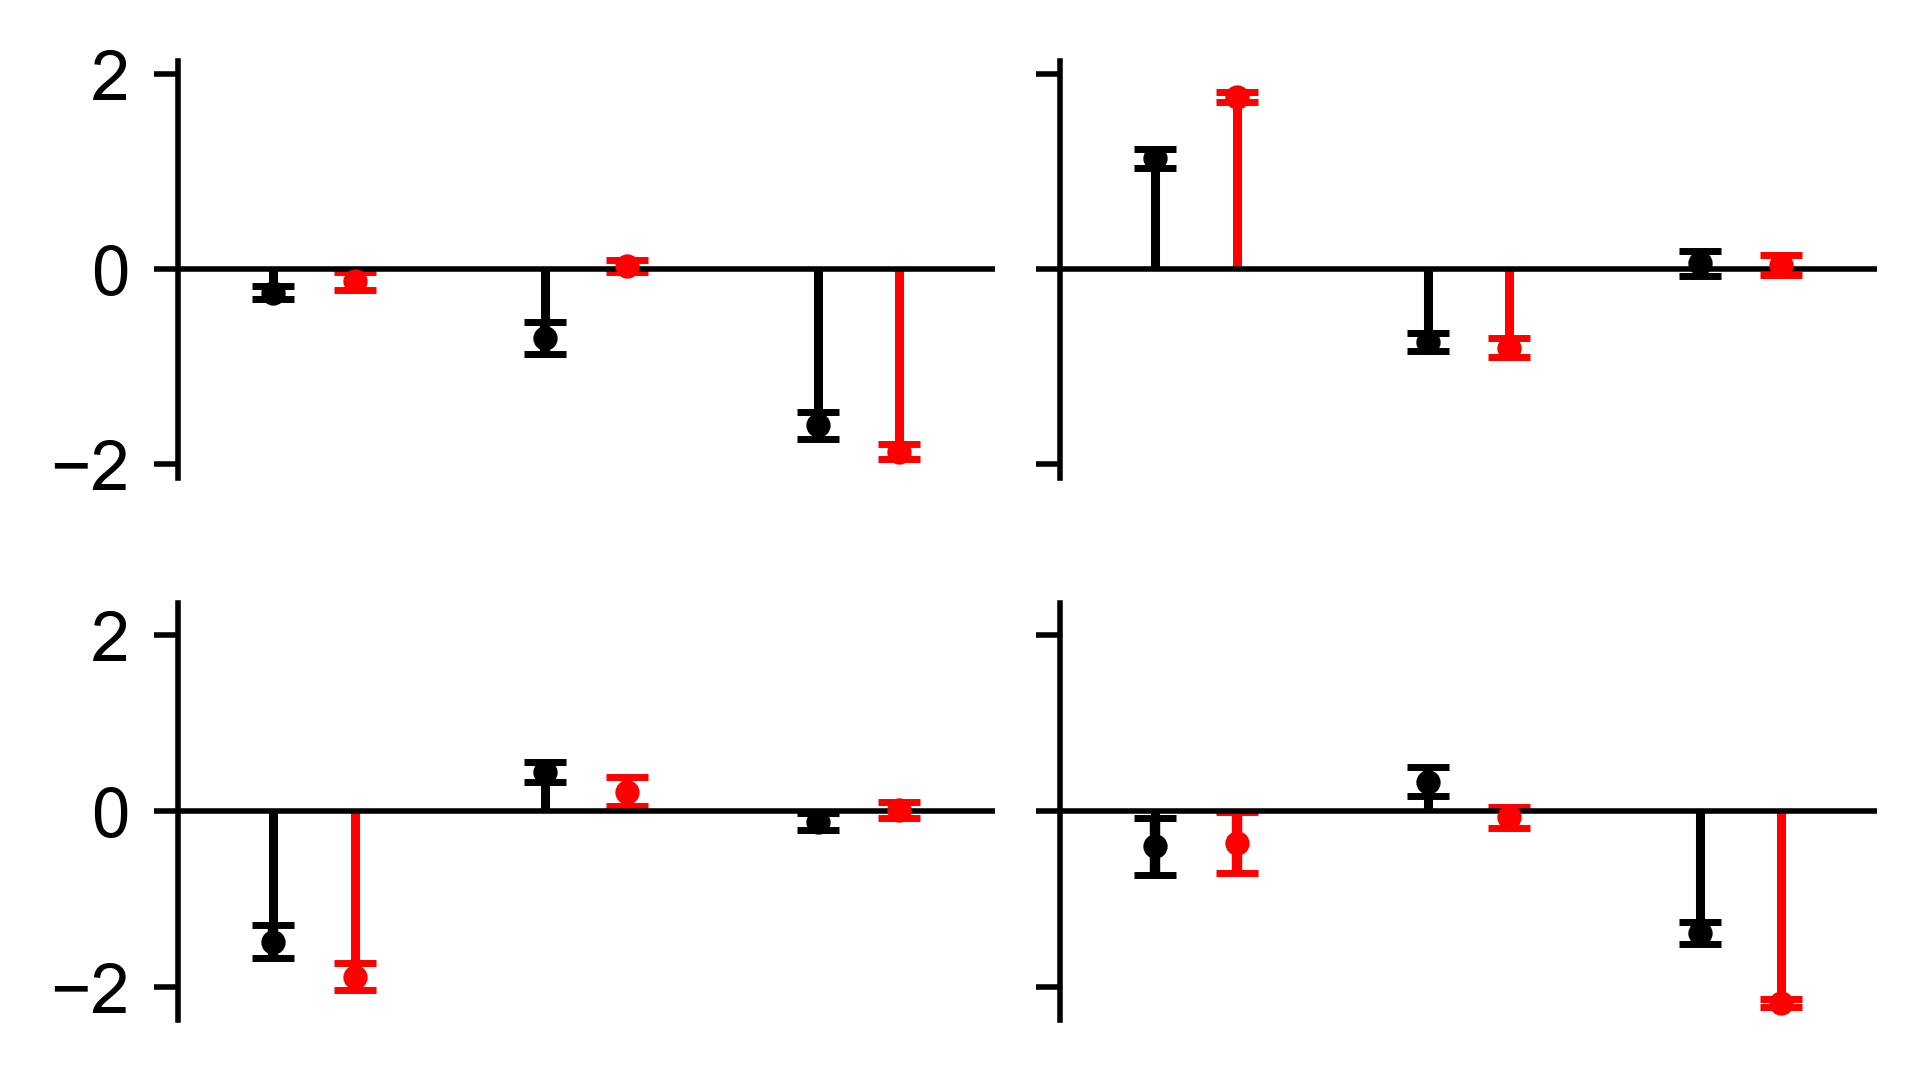

In [6]:
from scipy.stats import sem
import matplotlib.pyplot as plt

plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(4,2.5), dpi=500, sharey='row', sharex=True)
offset = 0.15
markersize = 5  # Independent variable for markersize
capsize = 3  # Independent variable for capsize

# Function to draw vertical lines from y=0 to the point
def draw_vlines(ax, positions, means, color):
    for pos, mean in zip(positions, means):
        ax.vlines(pos, 0, mean, colors=color, linewidth=1.3)

# Swap row 0 and 1
axes_row0 = axes[1]
axes_row1 = axes[0]

# Draw error bars and vertical lines for subjects coefficients
positions = np.arange(3) - offset
means_x = np.mean(subjects_coefs_x, axis=0).ravel()[:3]
axes_row0[0].errorbar(positions, means_x, yerr=sem(subjects_coefs_x, axis=0).ravel()[:3], 
                   capsize=capsize, fmt=".", c="k", markersize=markersize)
draw_vlines(axes_row0[0], positions, means_x, color="k")

means_y = np.mean(subjects_coefs_y, axis=0).ravel()[:3]
axes_row0[1].errorbar(positions, means_y, yerr=sem(subjects_coefs_y, axis=0).ravel()[:3], 
                   capsize=capsize, fmt=".", c="k", markersize=markersize)
draw_vlines(axes_row0[1], positions, means_y, color="k")

positions = np.arange(3) + offset
means_x = np.mean(models_coefs_x, axis=0).ravel()[:3]
axes_row0[0].errorbar(positions, means_x, yerr=sem(models_coefs_x, axis=0).ravel()[:3], 
                   capsize=capsize, fmt=".", c="r", markersize=markersize)
draw_vlines(axes_row0[0], positions, means_x, color="r")

means_y = np.mean(models_coefs_y, axis=0).ravel()[:3]
axes_row0[1].errorbar(positions, means_y, yerr=sem(models_coefs_y, axis=0).ravel()[:3], 
                   capsize=capsize, fmt=".", c="r", markersize=markersize)
draw_vlines(axes_row0[1], positions, means_y, color="r")

# Draw error bars and vertical lines for the remaining coefficients
positions = np.arange(3) - offset
means_x = np.mean(subjects_coefs_x, axis=0).ravel()[3:6]
axes_row1[0].errorbar(positions, means_x, yerr=sem(subjects_coefs_x, axis=0).ravel()[3:6], 
                   capsize=capsize, fmt=".", c="k", markersize=markersize)
draw_vlines(axes_row1[0], positions, means_x, color="k")

means_y = np.mean(subjects_coefs_y, axis=0).ravel()[3:6]
axes_row1[1].errorbar(positions, means_y, yerr=sem(subjects_coefs_y, axis=0).ravel()[3:6], 
                   capsize=capsize, fmt=".", c="k", markersize=markersize)
draw_vlines(axes_row1[1], positions, means_y, color="k")

positions = np.arange(3) + offset
means_x = np.mean(models_coefs_x, axis=0).ravel()[3:6]
axes_row1[0].errorbar(positions, means_x, yerr=sem(models_coefs_x, axis=0).ravel()[3:6], 
                   capsize=capsize, fmt=".", c="r", markersize=markersize)
draw_vlines(axes_row1[0], positions, means_x, color="r")

means_y = np.mean(models_coefs_y, axis=0).ravel()[3:6]
axes_row1[1].errorbar(positions, means_y, yerr=sem(models_coefs_y, axis=0).ravel()[3:6], 
                   capsize=capsize, fmt=".", c="r", markersize=markersize)
draw_vlines(axes_row1[1], positions, means_y, color="r")

plt.tight_layout()
plt.subplots_adjust(wspace=0.08, hspace=0.3)

for ax in axes.flatten():
    ax.set_xlim((-0.5, 2.5))
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels([''] * 3)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
    y_max = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
    ax.set_ylim(-y_max, y_max)
    for tick in ax.get_yticklabels():
        tick.set_fontname("Arial")
    for tick in ax.get_xticklabels():
        tick.set_fontname("Arial")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(bottom=False)

plt.show()